In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df=pd.read_csv("data\\loan_approval_dataset.csv")

### EDA

In [10]:
df.head(5)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


no of row and column


In [11]:
df.shape

(4269, 13)

dataset info

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


In [13]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


null value

In [14]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

duplicated value

In [15]:
df.duplicated().sum()

np.int64(0)

not information column remove

In [16]:
df_cleaned=df.drop("loan_id",axis=1)

In [17]:
df_cleaned.columns=df_cleaned.columns.str.strip()

numerical vs numerical

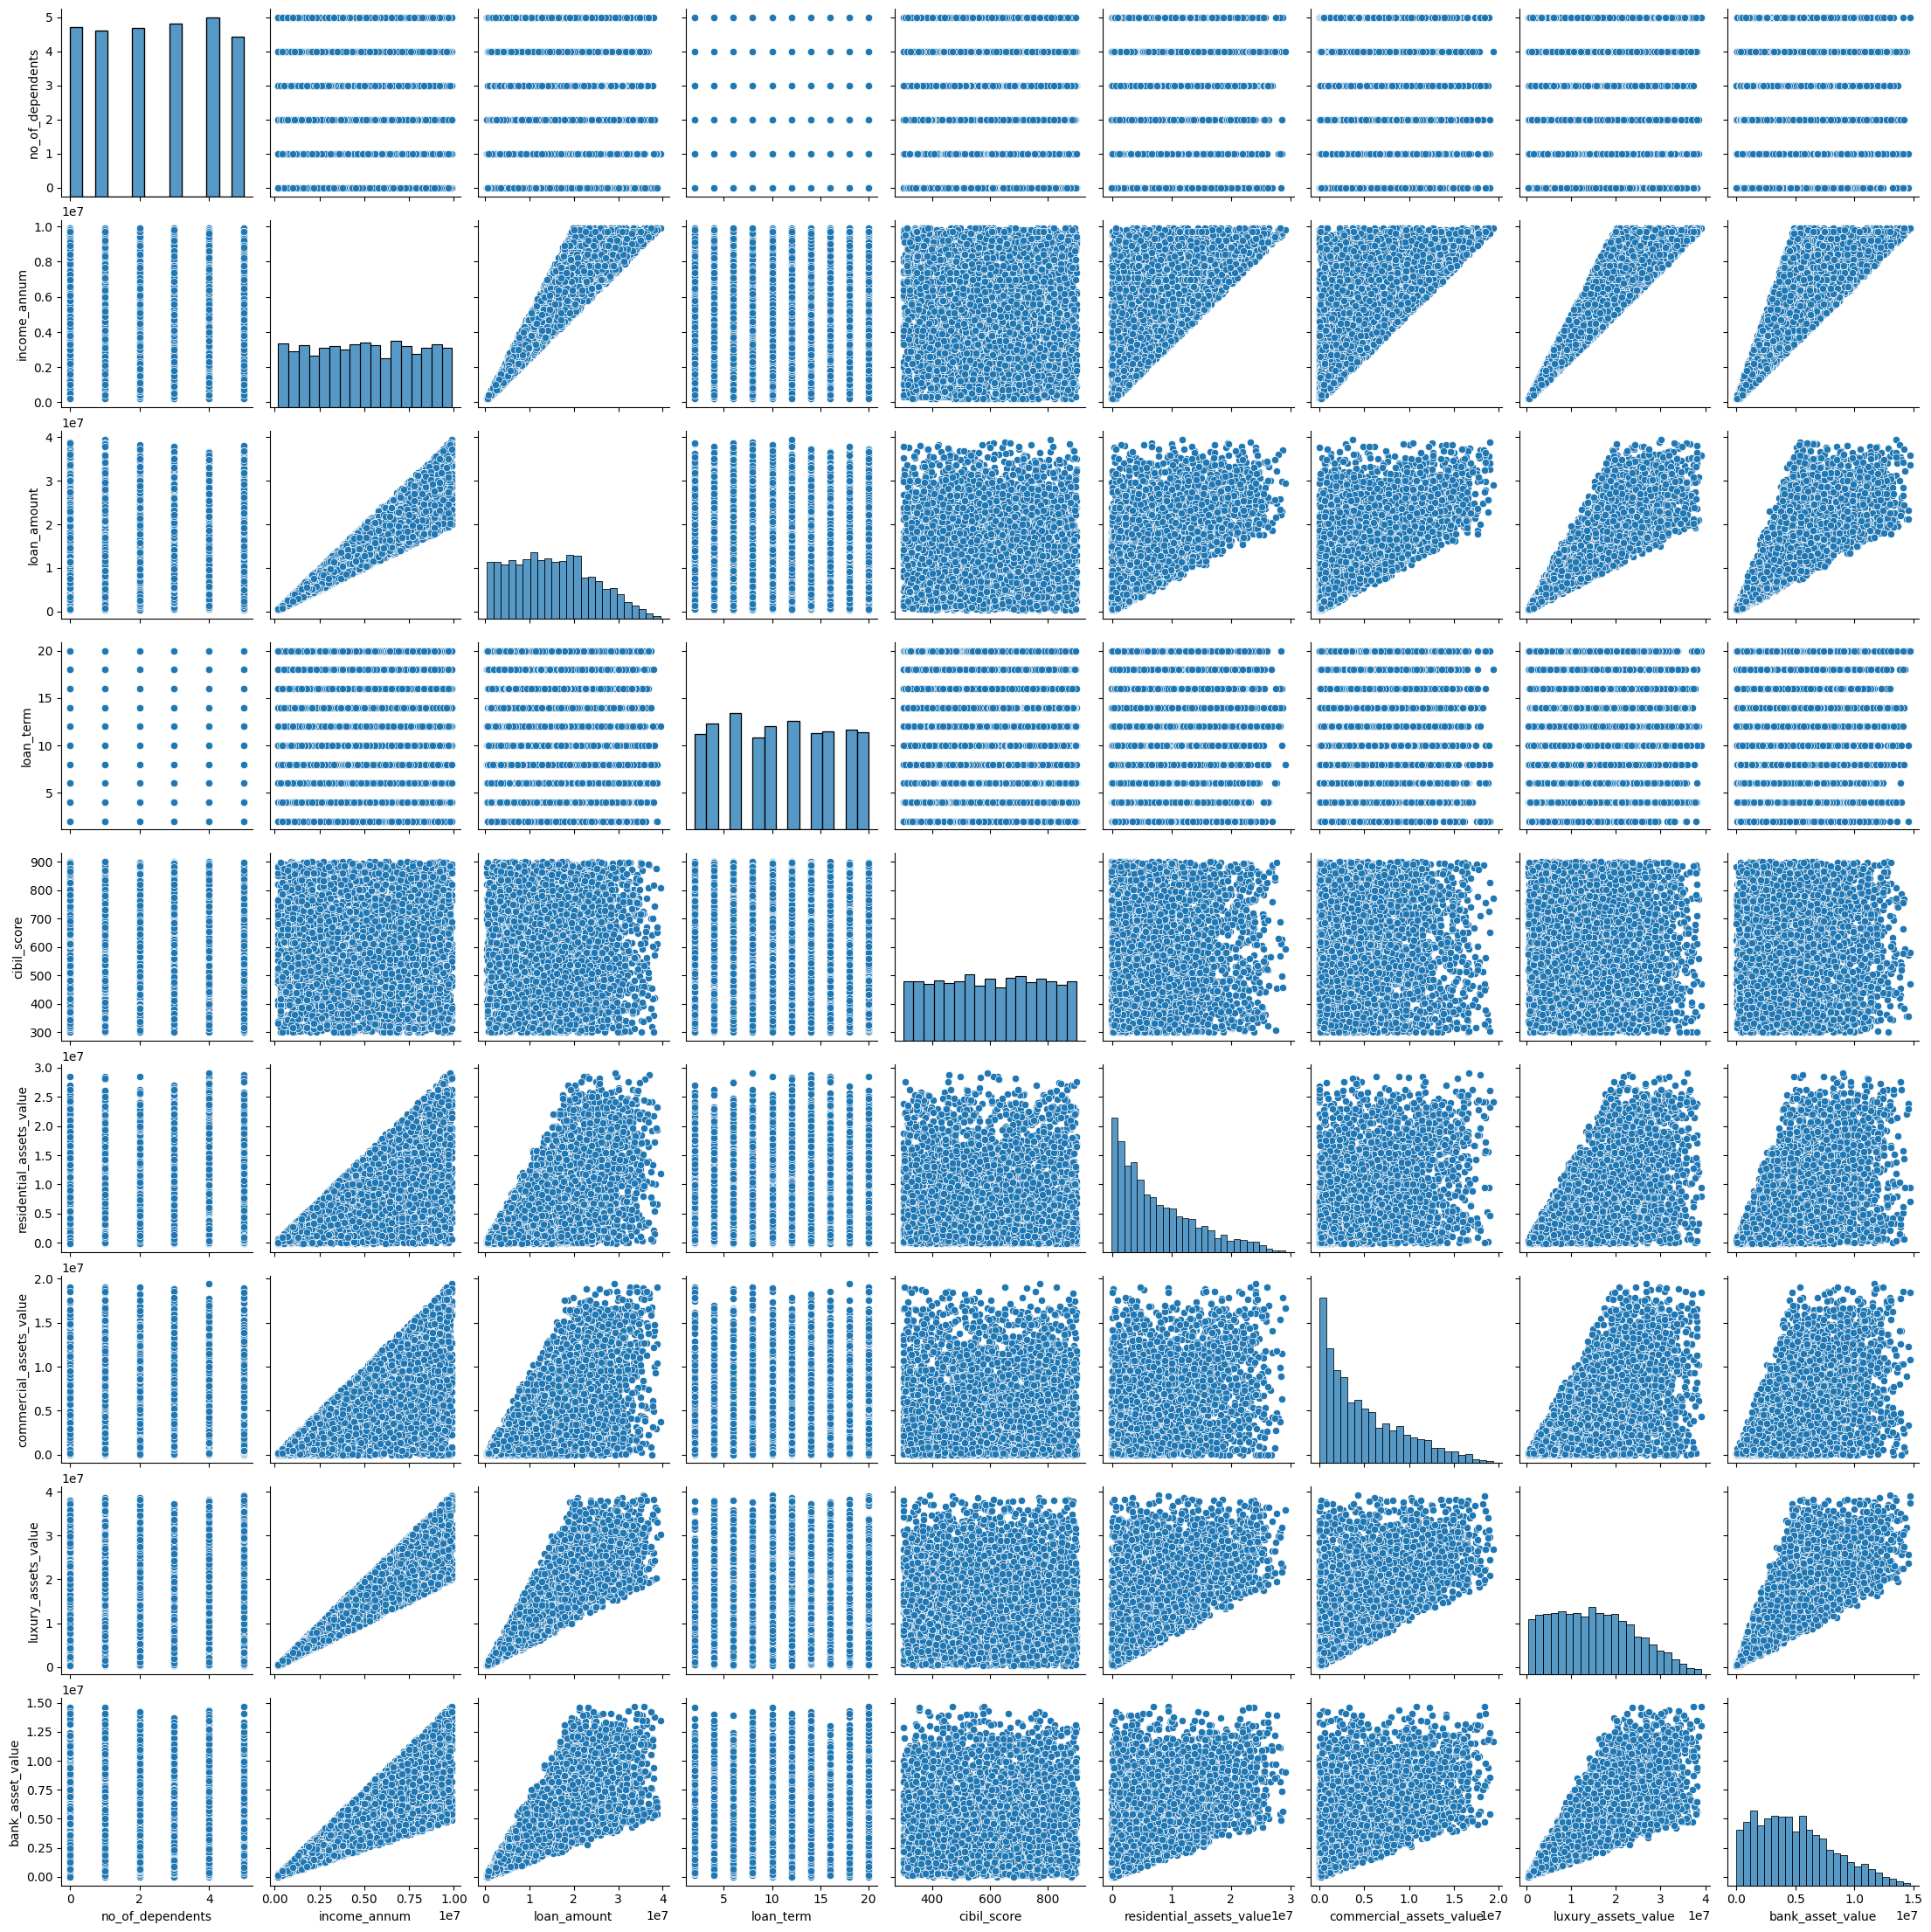

In [18]:
sns.pairplot(df_cleaned)

countplot of education

<Axes: xlabel='education', ylabel='count'>

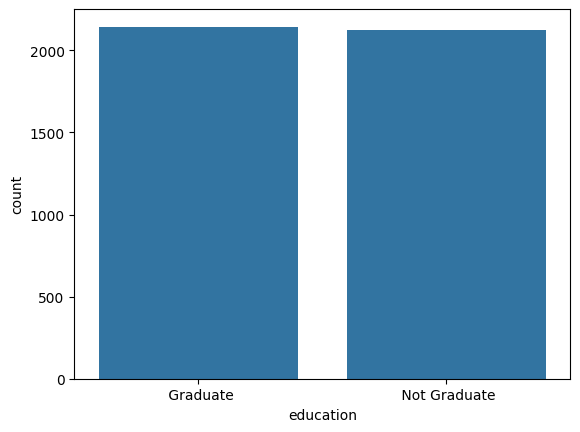

In [19]:
sns.countplot(x=df_cleaned["education"])

countplot of self employed

<Axes: xlabel='self_employed', ylabel='count'>

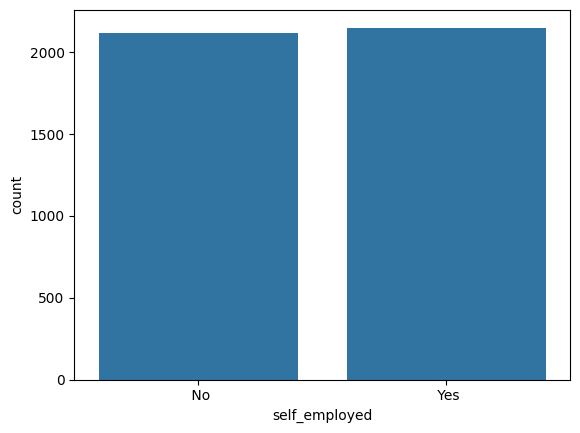

In [20]:
sns.countplot(x=df_cleaned["self_employed"])

heatmap

<Axes: >

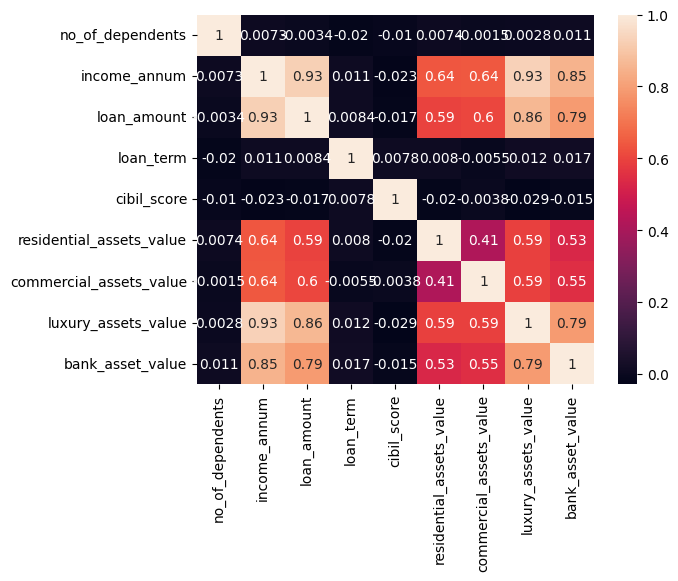

In [21]:
corr=df_cleaned.corr(numeric_only=True)
sns.heatmap(corr,annot=True,fmt=".2g")

value_counts

In [22]:
df_cleaned["education"].value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [23]:
df_cleaned["self_employed"].value_counts()

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

### outliers Handle

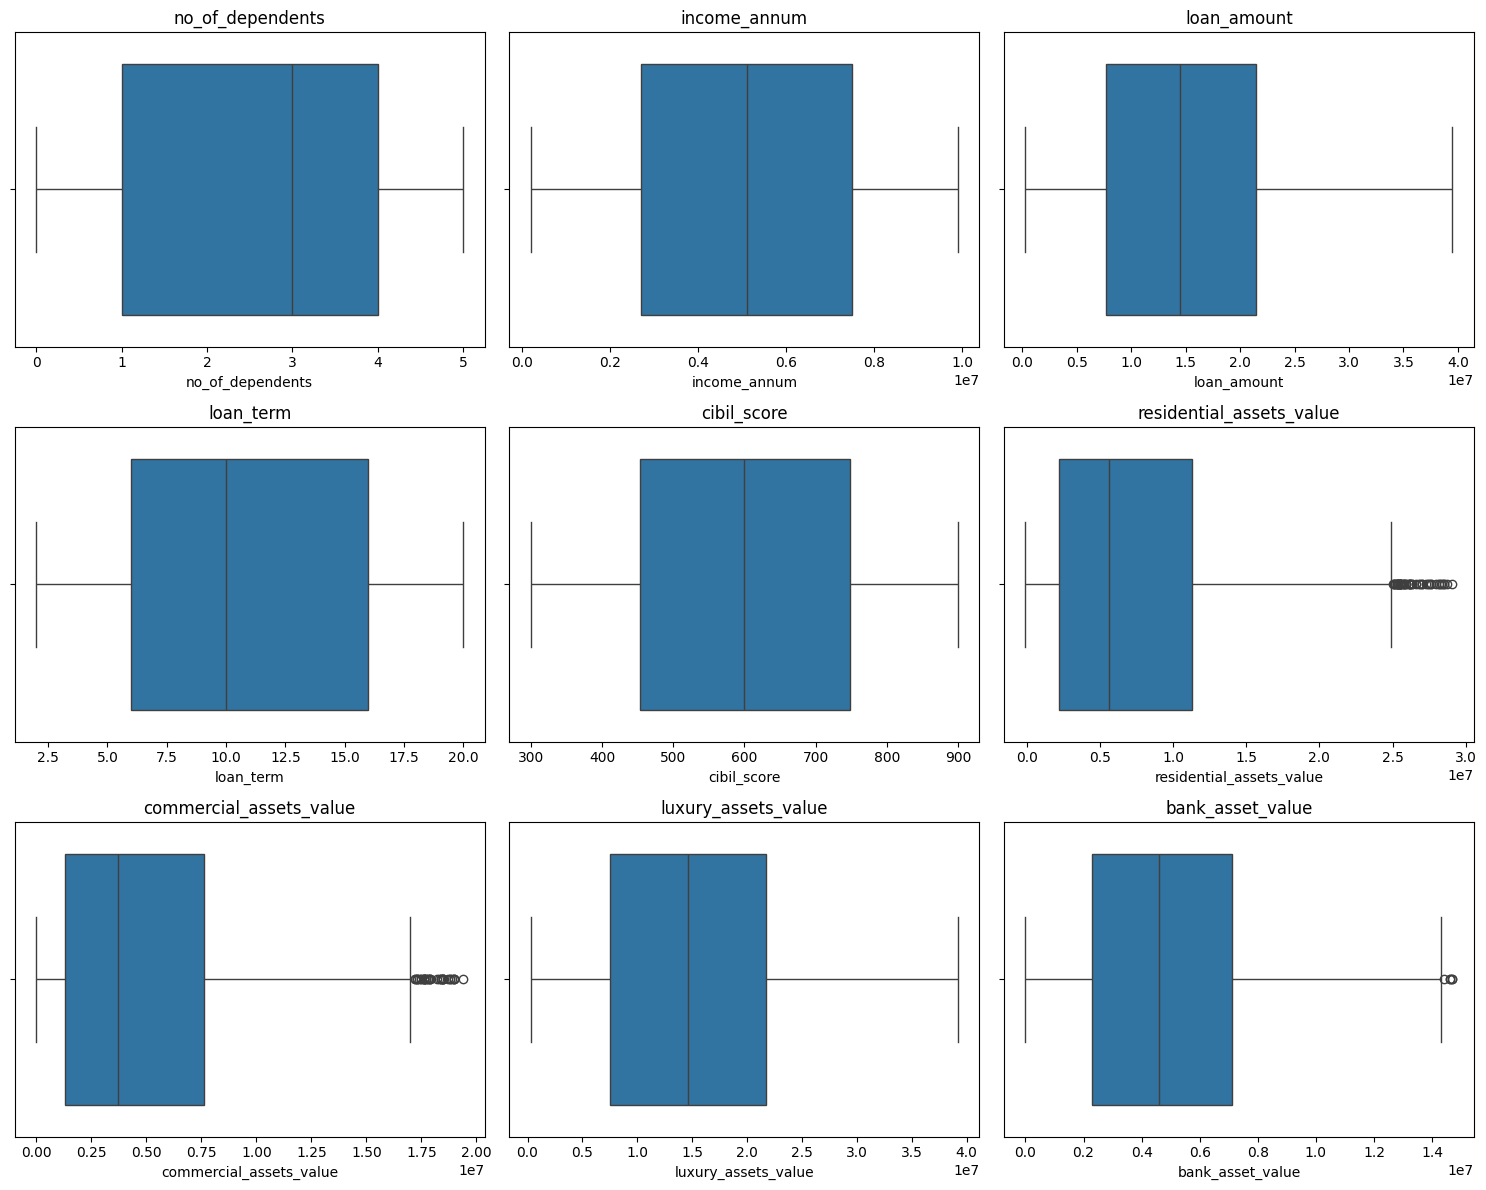

In [24]:
num_cols = df_cleaned.select_dtypes("number").columns

plt.figure(figsize=(15, 12))

for j, i in enumerate(num_cols, 1):
    plt.subplot(3, 3, j)
    sns.boxplot(x=df_cleaned[i])
    plt.title(i)

plt.tight_layout()
plt.show()

In [25]:
outliers_columns=["residential_assets_value","commercial_assets_value","bank_asset_value"]

In [26]:
for i in outliers_columns:
    Q3=df_cleaned[i].quantile(0.75)
    Q1=df_cleaned[i].quantile(0.25)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    outliers=df_cleaned[(df_cleaned[i]<lower)|(df_cleaned[i]>upper)]
    df_cleaned[i]=df_cleaned[i].clip(lower=lower,upper=upper)
    print("i",outliers.shape[0])

i 52
i 37
i 5


### after handle outliers

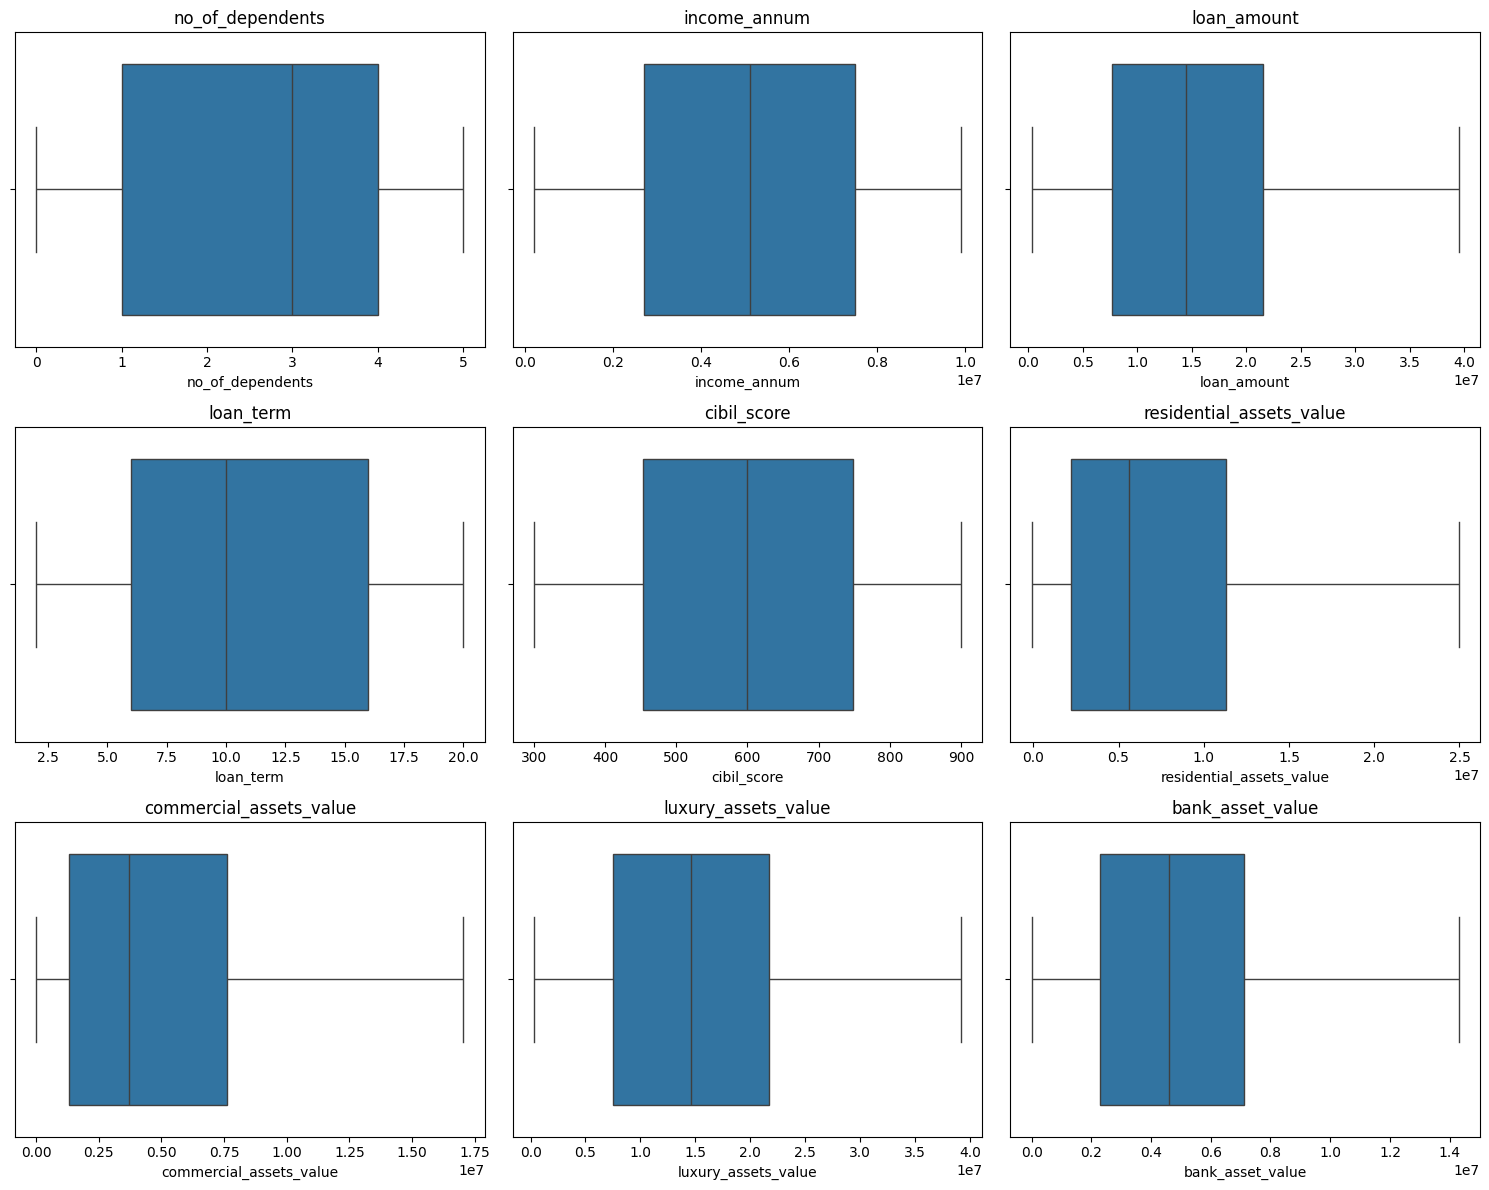

In [27]:
plt.figure(figsize=(15, 12))

for j, i in enumerate(num_cols, 1):
    plt.subplot(3, 3, j)
    sns.boxplot(x=df_cleaned[i])
    plt.title(i)

plt.tight_layout()
plt.show()

value_counts of target

In [28]:
df_cleaned["loan_status"].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

### train test split

In [29]:
from sklearn.model_selection import train_test_split,RandomizedSearchCV

In [30]:
x=df_cleaned.drop("loan_status",axis=1)
y=df_cleaned["loan_status"]


x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)


In [31]:
y_train=y_train.str.strip()
y_test=y_test.str.strip()

In [32]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [33]:
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score

In [34]:
num_cols=x_train.select_dtypes("number").columns
cat_cols=x_train.select_dtypes("str").columns

columntransformer

In [35]:
process=ColumnTransformer([
    ("encoding",OneHotEncoder(handle_unknown="ignore"),cat_cols),
    ("scaling",StandardScaler(),num_cols)
])

### logistic Regression

In [36]:
model_lr=Pipeline(steps=[
    ("ColumnTransformer",process),
    ("linear_model",LogisticRegression(max_iter=1000,random_state=42))
])
model_lr.fit(x_train,y_train)
y_pred=model_lr.predict(x_test)
y_pred_train=model_lr.predict(x_train)


train_acc_lr = accuracy_score(y_train, y_pred_train)
test_acc_lr = accuracy_score(y_test, y_pred)

train_prec_lr = precision_score(y_train, y_pred_train, pos_label="Approved")
test_prec_lr = precision_score(y_test, y_pred, pos_label="Approved")

train_rec_lr = recall_score(y_train, y_pred_train, pos_label="Approved")
test_rec_lr = recall_score(y_test, y_pred, pos_label="Approved")

train_f1_lr = f1_score(y_train, y_pred_train, pos_label="Approved")
test_f1_lr = f1_score(y_test, y_pred, pos_label="Approved")

# training accuracy
print("traing accuracy")
print("accuracy_score :",train_acc_lr)
print("f1_score :",train_f1_lr)
print("recall_score :",train_rec_lr)
print("precision :",train_prec_lr)

# testing accuracy
print("testing accuracy")
print("accuracy_score :",test_acc_lr)
print("f1_score :",test_f1_lr)
print("recall_score :",test_rec_lr)
print("precision :",test_prec_lr)

traing accuracy
accuracy_score : 0.9150805270863837
f1_score : 0.9319887429643527
recall_score : 0.9350588235294117
precision : 0.9289387564282375
testing accuracy
accuracy_score : 0.9215456674473068
f1_score : 0.9377901578458682
recall_score : 0.9510357815442562
precision : 0.924908424908425


### Naive_Bayes

In [37]:
from sklearn.naive_bayes import BernoulliNB

In [38]:
model_nb=Pipeline(steps=[
    ("ColumnTransformer",process),
    ("nb",BernoulliNB())
])
model_nb.fit(x_train,y_train)
y_pred_nb=model_nb.predict(x_test)
y_pred_2=model_nb.predict(x_train)


train_acc_nb = accuracy_score(y_train, y_pred_2)
test_acc_nb = accuracy_score(y_test, y_pred_nb)

train_prec_nb = precision_score(y_train, y_pred_2, pos_label="Approved")
test_prec_nb = precision_score(y_test, y_pred_nb, pos_label="Approved")

train_rec_nb = recall_score(y_train, y_pred_2, pos_label="Approved")
test_rec_nb = recall_score(y_test, y_pred_nb, pos_label="Approved")

train_f1_nb = f1_score(y_train, y_pred_2, pos_label="Approved")
test_f1_nb = f1_score(y_test, y_pred_nb, pos_label="Approved")

# training accuracy
print("training accuracy")
print("accuracy_score :",train_acc_nb)
print("f1_score :",train_f1_nb)
print("recall_score :",train_rec_nb)
print("precision :",train_prec_nb)


# testing accuracy
print("testing accuracy")
print("accuracy_score :",test_acc_nb)
print("f1_score :",test_f1_nb)
print("recall_score :",test_rec_nb)
print("precision :",test_prec_nb)

training accuracy
accuracy_score : 0.8696925329428989
f1_score : 0.8835383407484951
recall_score : 0.7943529411764706
precision : 0.9952830188679245
testing accuracy
accuracy_score : 0.8946135831381733
f1_score : 0.9079754601226994
recall_score : 0.8361581920903954
precision : 0.9932885906040269


### SVM

In [39]:
from sklearn.svm import SVC

In [40]:
model_svc=Pipeline(steps=[
    ("ColumnTransformer",process),
    ("svc",SVC())
])
model_svc.fit(x_train,y_train)
y_pred_svc=model_svc.predict(x_test)
y_pred_3=model_svc.predict(x_train)

train_acc_svc = accuracy_score(y_train, y_pred_3)
test_acc_svc = accuracy_score(y_test, y_pred_svc)

train_prec_svc = precision_score(y_train, y_pred_3, pos_label="Approved")
test_prec_svc = precision_score(y_test, y_pred_svc, pos_label="Approved")

train_rec_svc = recall_score(y_train, y_pred_3, pos_label="Approved")
test_rec_svc = recall_score(y_test, y_pred_svc, pos_label="Approved")

train_f1_svc = f1_score(y_train, y_pred_3, pos_label="Approved")
test_f1_svc = f1_score(y_test, y_pred_svc, pos_label="Approved")

# training accuracy
print("training accuracy")
print("accuracy_score :",train_acc_svc)
print("f1_score :",train_f1_svc)
print("recall_score :",train_rec_svc)
print("precision :",train_prec_svc)

# testing accuracy
print("testing accuracy")
print("accuracy_score :",test_acc_svc)
print("f1_score :",test_f1_svc)
print("recall_score :",test_rec_svc)
print("precision :",test_prec_svc)

training accuracy
accuracy_score : 0.9566617862371889
f1_score : 0.9650613786591123
recall_score : 0.9618823529411765
precision : 0.9682614874467077
testing accuracy
accuracy_score : 0.9449648711943794
f1_score : 0.9561975768872321
recall_score : 0.9661016949152542
precision : 0.9464944649446494


### knn

In [41]:
from sklearn.neighbors import KNeighborsClassifier

In [52]:
model_knn=Pipeline(steps=[
    ("ColumnTransformer",process),
    ("knn",KNeighborsClassifier())
])
model_knn.fit(x_train,y_train)
y_pred_knn=model_knn.predict(x_test)
y_pred_4=model_knn.predict(x_train)

train_acc_knn = accuracy_score(y_train, y_pred_4)
test_acc_knn = accuracy_score(y_test, y_pred_knn)

train_prec_knn = precision_score(y_train, y_pred_4, pos_label="Approved")
test_prec_knn = precision_score(y_test, y_pred_knn, pos_label="Approved")

train_rec_knn = recall_score(y_train, y_pred_4, pos_label="Approved")
test_rec_knn = recall_score(y_test, y_pred_knn, pos_label="Approved")

train_f1_knn = f1_score(y_train, y_pred_4, pos_label="Approved")
test_f1_knn = f1_score(y_test, y_pred_knn, pos_label="Approved")

# training accuracy
print("training accuracy")
print("accuracy_score :",train_acc_knn)
print("f1_score :",train_f1_knn)
print("recall_score :",train_rec_knn)
print("precision :",train_prec_knn)

# testing accuracy
print("testing accuracy")
print("accuracy_score :",test_acc_knn)
print("f1_score :",test_f1_knn)
print("recall_score :",test_rec_knn)
print("precision :",test_prec_knn)


training accuracy
accuracy_score : 0.9443631039531479
f1_score : 0.9553361542078044
recall_score : 0.9562352941176471
precision : 0.9544387036167215
testing accuracy
accuracy_score : 0.9004683840749415
f1_score : 0.9210770659238626
recall_score : 0.9340866290018832
precision : 0.9084249084249084


### decision tree

In [43]:
from sklearn.tree import DecisionTreeClassifier

In [44]:
model_dt=Pipeline(steps=[
    ("ColumnTransformer",process),
    ("tree",DecisionTreeClassifier())
])
model_dt.fit(x_train,y_train)
y_pred_dt=model_dt.predict(x_test)
y_pred_5=model_dt.predict(x_train)

train_acc_dt = accuracy_score(y_train, y_pred_5)
test_acc_dt = accuracy_score(y_test, y_pred_dt)

train_prec_dt = precision_score(y_train, y_pred_5, pos_label="Approved")
test_prec_dt = precision_score(y_test, y_pred_dt, pos_label="Approved")

train_rec_dt = recall_score(y_train, y_pred_5, pos_label="Approved")
test_rec_dt = recall_score(y_test, y_pred_dt, pos_label="Approved")

train_f1_dt = f1_score(y_train, y_pred_5, pos_label="Approved")
test_f1_dt = f1_score(y_test, y_pred_dt, pos_label="Approved")


# training accuracy
print("training accuracy")
print("accuracy_score :",train_acc_dt)
print("f1_score :",train_f1_dt)
print("recall_score :",train_rec_dt)
print("precision :",train_prec_dt)


# testing accuracy
print("testing accuracy")
print("accuracy_score :",test_acc_dt)
print("f1_score :",test_f1_dt)
print("recall_score :",test_rec_dt)
print("precision :",test_prec_dt)


training accuracy
accuracy_score : 1.0
f1_score : 1.0
recall_score : 1.0
precision : 1.0
testing accuracy
accuracy_score : 0.9789227166276346
f1_score : 0.983177570093458
recall_score : 0.9905838041431262
precision : 0.9758812615955473


### random forest

In [45]:
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier

In [46]:
model_rf=Pipeline(steps=[
    ("ColumnTransformer",process),
    ("forest",RandomForestClassifier())
])
model_rf.fit(x_train,y_train)
y_pred_rf=model_rf.predict(x_test)
y_pred_6=model_rf.predict(x_train)

train_acc_rf = accuracy_score(y_train, y_pred_6)
test_acc_rf = accuracy_score(y_test, y_pred_rf)

train_prec_rf = precision_score(y_train, y_pred_6, pos_label="Approved")
test_prec_rf = precision_score(y_test, y_pred_rf, pos_label="Approved")

train_rec_rf = recall_score(y_train, y_pred_6, pos_label="Approved")
test_rec_rf = recall_score(y_test, y_pred_rf, pos_label="Approved")

train_f1_rf = f1_score(y_train, y_pred_6, pos_label="Approved")
test_f1_rf = f1_score(y_test, y_pred_rf, pos_label="Approved")

# training accuracy
print("training accuracy")
print("accuracy_score :",train_acc_rf)
print("f1_score :",train_f1_rf)
print("recall_score :",train_rec_rf)
print("precision :",train_prec_rf)


# testing accuracy
print("testing accuracy")
print("accuracy_score :",test_acc_rf)
print("f1_score :",test_f1_rf)
print("recall_score :",test_rec_rf)
print("precision :",test_prec_rf)

training accuracy
accuracy_score : 1.0
f1_score : 1.0
recall_score : 1.0
precision : 1.0
testing accuracy
accuracy_score : 0.9836065573770492
f1_score : 0.9869402985074627
recall_score : 0.9962335216572504
precision : 0.977818853974122


### adaboost

In [47]:
model_ada=Pipeline(steps=[
    ("ColumnTransformer",process),
    ("ada",AdaBoostClassifier())
])
model_ada.fit(x_train,y_train)
y_pred_ad=model_ada.predict(x_test)
y_pred_7=model_ada.predict(x_train)
train_acc_ad = accuracy_score(y_train, y_pred_7)
test_acc_ad = accuracy_score(y_test, y_pred_ad)

train_prec_ad = precision_score(y_train, y_pred_7, pos_label="Approved")
test_prec_ad = precision_score(y_test, y_pred_ad, pos_label="Approved")

train_rec_ad = recall_score(y_train, y_pred_7, pos_label="Approved")
test_rec_ad = recall_score(y_test, y_pred_ad, pos_label="Approved")

train_f1_ad = f1_score(y_train, y_pred_7, pos_label="Approved")
test_f1_ad = f1_score(y_test, y_pred_ad, pos_label="Approved")

# training accuracy
print("training accuracy")
print("accuracy_score :",train_acc_ad)
print("f1_score :",train_f1_ad)
print("recall_score :",train_rec_ad)
print("precision :",train_prec_ad)

# training accuracy
print("training accuracy")
print("accuracy_score :",test_acc_ad)
print("f1_score :",test_f1_ad)
print("recall_score :",test_rec_ad)
print("precision :",test_prec_ad)


training accuracy
accuracy_score : 0.9657393850658857
f1_score : 0.9728727104103873
recall_score : 0.9872941176470589
precision : 0.9588665447897623
training accuracy
accuracy_score : 0.9742388758782201
f1_score : 0.9795158286778398
recall_score : 0.9905838041431262
precision : 0.9686924493554327


### model comperison table

In [48]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "SVM",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "AdaBoost"
    ],

    "Train Accuracy": [
        train_acc_lr,
        train_acc_nb,
        train_acc_svc,
        train_acc_knn,
        train_acc_dt,
        train_acc_rf,
        train_acc_ad
    ],

    "Test Accuracy": [
        test_acc_lr,
        test_acc_nb,
        test_acc_svc,
        test_acc_knn,
        test_acc_dt,
        test_acc_rf,
        test_acc_ad
    ],

    "Train Precision": [
        train_prec_lr,
        train_prec_nb,
        train_prec_svc,
        train_prec_knn,
        train_prec_dt,
        train_prec_rf,
        train_prec_ad
    ],

    "Test Precision": [
        test_prec_lr,
        test_prec_nb,
        test_prec_svc,
        test_prec_knn,
        test_prec_dt,
        test_prec_rf,
        test_prec_ad
    ],

    "Train Recall": [
        train_rec_lr,
        train_rec_nb,
        train_rec_svc,
        train_rec_knn,
        train_rec_dt,
        train_rec_rf,
        train_rec_ad
    ],

    "Test Recall": [
        test_rec_lr,
        test_rec_nb,
        test_rec_svc,
        test_rec_knn,
        test_rec_dt,
        test_rec_rf,
        test_rec_ad
    ],

    "Train F1": [
        train_f1_lr,
        train_f1_nb,
        train_f1_svc,
        train_f1_knn,
        train_f1_dt,
        train_f1_rf,
        train_f1_ad
    ],

    "Test F1": [
        test_f1_lr,
        test_f1_nb,
        test_f1_svc,
        test_f1_knn,
        test_f1_dt,
        test_f1_rf,
        test_f1_ad
    ]
})

model_comparison

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,Logistic Regression,0.915081,0.921546,0.928939,0.924908,0.935059,0.951036,0.931989,0.937790
1,Naive Bayes,0.869693,0.894614,0.995283,0.993289,0.794353,0.836158,0.883538,0.907975
2,SVM,0.956662,0.944965,0.968261,0.946494,0.961882,0.966102,0.965061,0.956198
3,KNN,0.944363,0.900468,0.954439,0.908425,0.956235,0.934087,0.955336,0.921077
4,Decision Tree,1.000000,0.978923,1.000000,0.975881,1.000000,0.990584,1.000000,0.983178
5,Random Forest,1.000000,0.983607,1.000000,0.977819,1.000000,0.996234,1.000000,0.986940
6,AdaBoost,0.965739,0.974239,0.958867,0.968692,0.987294,0.990584,0.972873,0.979516


### hyperparameter tuning

logistic regression

In [49]:
param_grid =  {
    "linear_model__C": [0.01, 0.1, 1, 10, 100],
    "linear_model__solver": ["lbfgs"],
    "linear_model__penalty": ["l2"],
}

In [53]:
random_lr=RandomizedSearchCV(
    estimator=model_lr,
    param_distributions=param_grid,
    cv=5,
    n_jobs=-1,
    n_iter=5,
    scoring="accuracy",
    random_state=42
)
random_lr.fit(x_train,y_train)

c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'linear_model__C': [0.01, 0.1, ...], 'linear_model__penalty': ['l2'], 'linear_model__solver': ['lbfgs']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluati

In [51]:
random_lr.best_params_
print(random_lr.best_score_)

0.9118594436310395
